Modulations : ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
SNRs : [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]


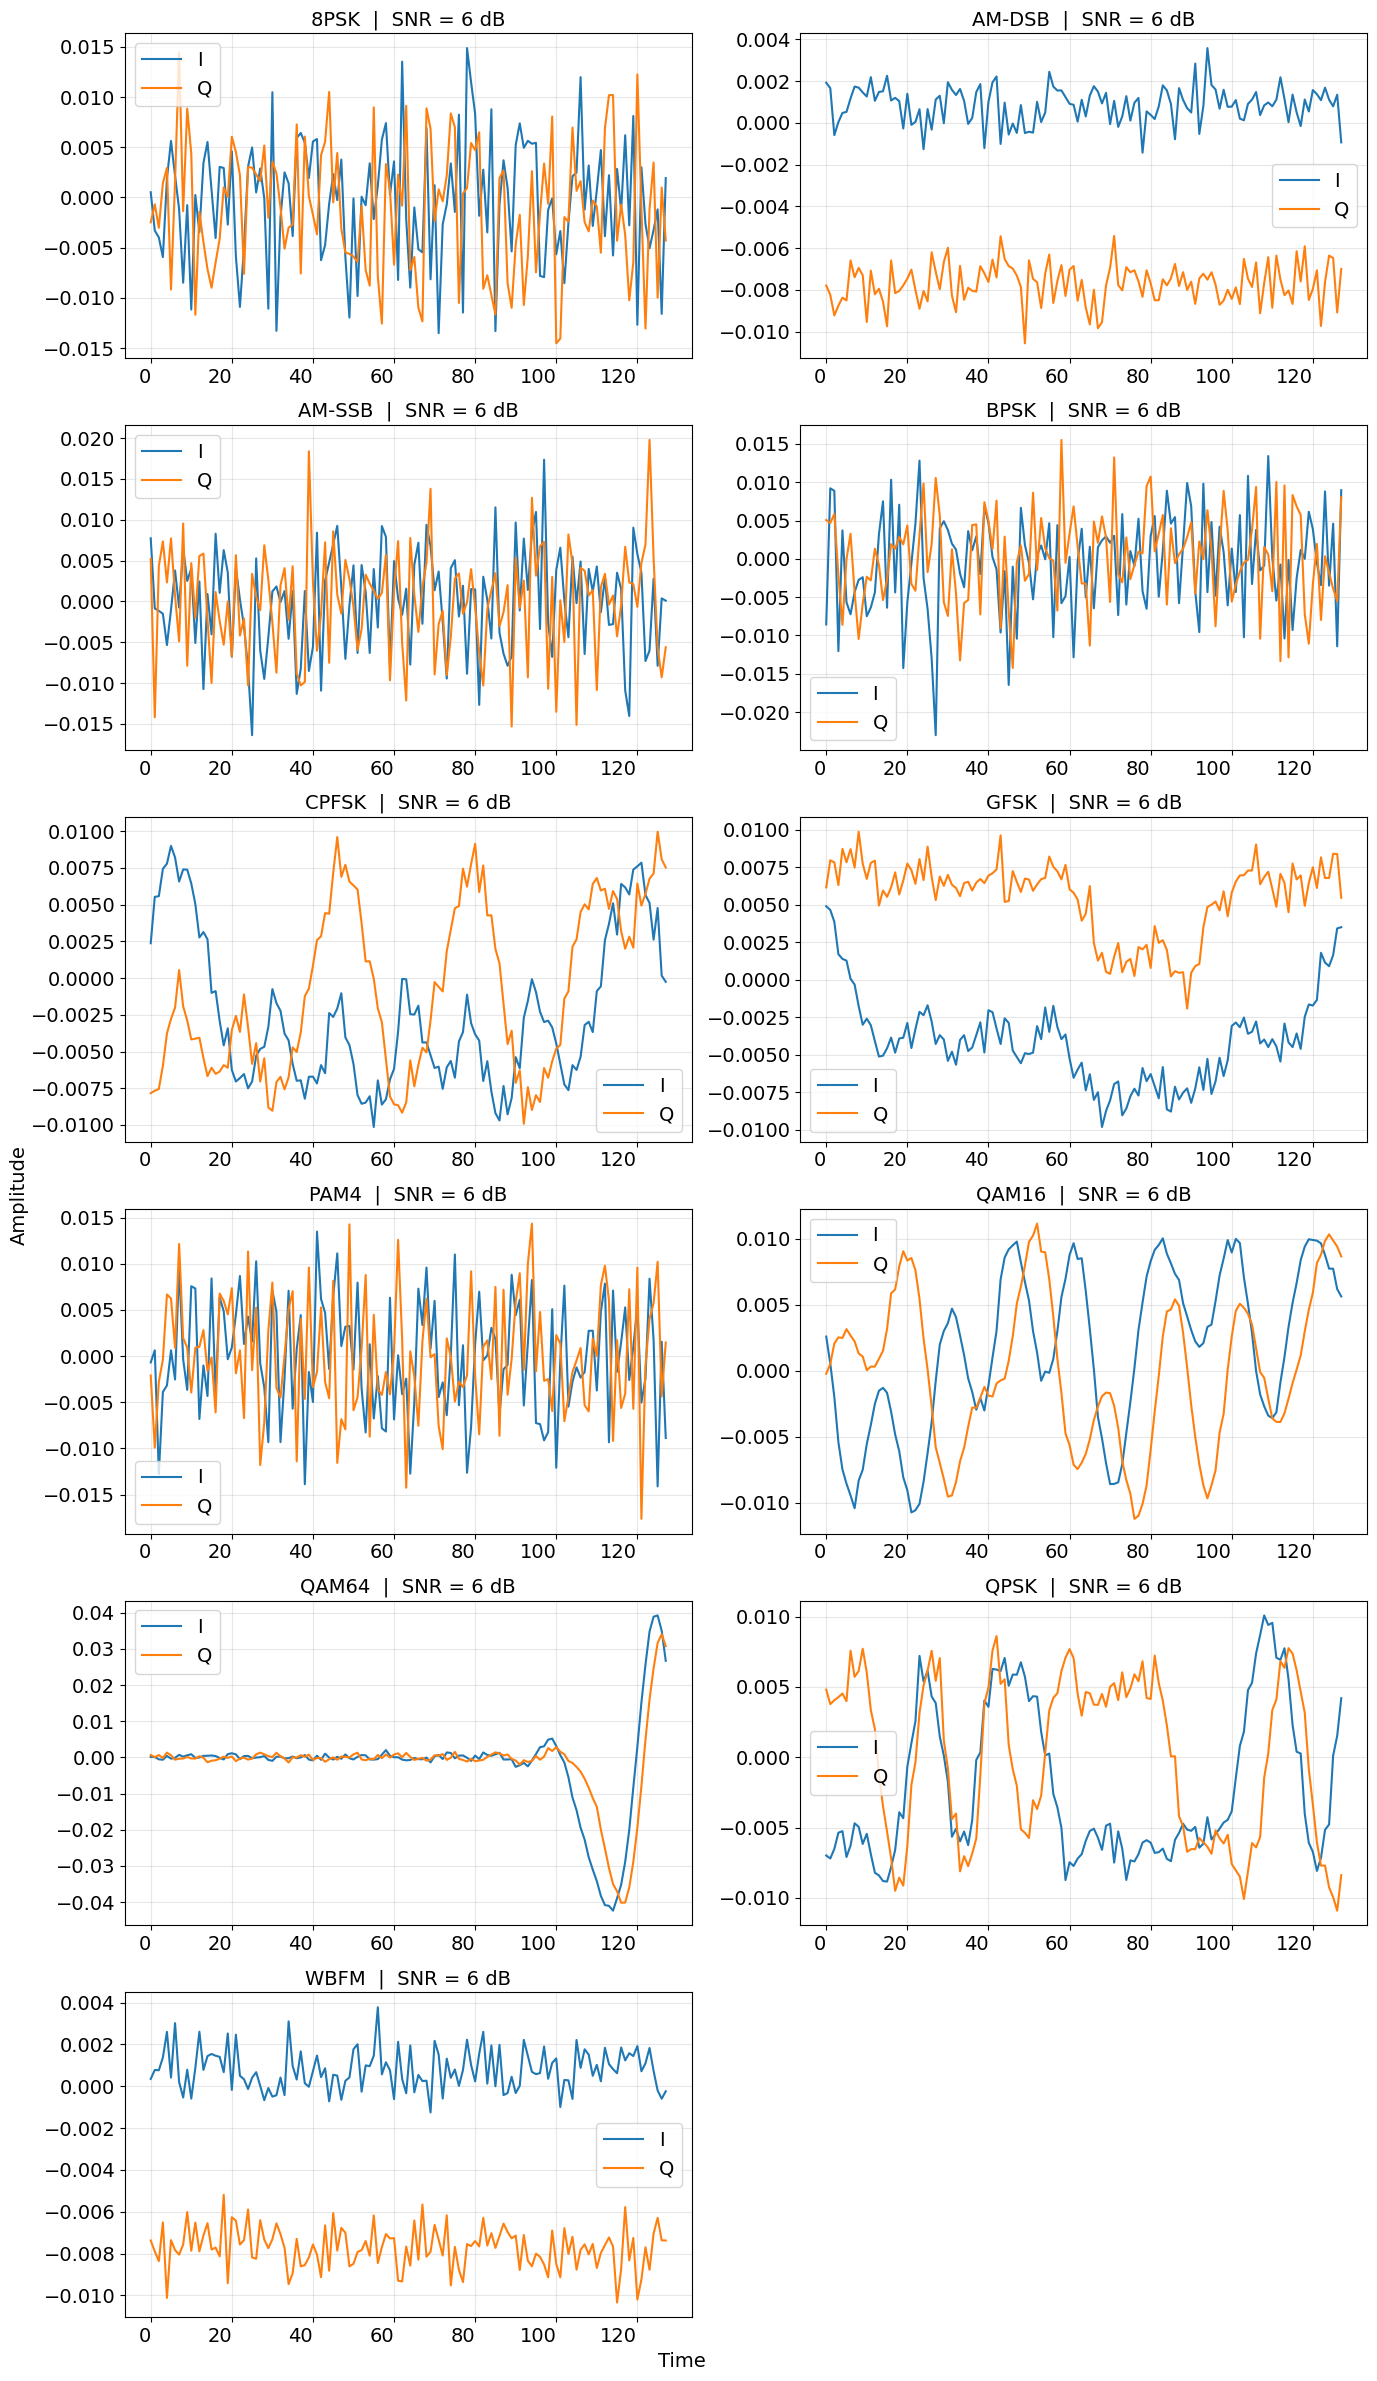

In [6]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import math

# =================================
# 1) Load  RadioML2016.10a dataset
# ================================
pkl_path = "C:/Users/MSI/Pictures/Mourad/RadioML2016/RadioML_2016_10A/RML2016.10a_dict.pkl"   

with open(pkl_path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

mods = sorted(list(set(k[0] for k in data.keys())))
snrs = sorted(list(set(k[1] for k in data.keys())))

print("Modulations :", mods)
print("SNRs :", snrs)

# ===============================
# 2) Selection of SNR and sample
# ===============================
chosen_snr = 6      
sample_idx = 0       

# Check that the SNR exists
if chosen_snr not in snrs:
    raise ValueError(f"SNR {chosen_snr} non trouvé dans le dataset.")

# ======================
# 3) Prepare the figure
# ======================
n_mods = len(mods)
ncols = 2
nrows = math.ceil(n_mods / ncols)

fig = plt.figure(figsize=(14, 4 * nrows))

# =========================
# 4) Trace each modulation
# =========================
for i, mod in enumerate(mods, 1):
    samples = np.array(data[(mod, chosen_snr)])
    sample = samples[sample_idx]

    if sample.shape == (2, 128):
        I = sample[0]
        Q = sample[1]
    elif sample.shape == (128, 2):
        I = sample[:, 0]
        Q = sample[:, 1]
    else:
        raise ValueError(f"Shape inattendue pour {mod}: {sample.shape}")

    plt.subplot(nrows, ncols, i)
    plt.plot(I, label="I")
    plt.plot(Q, label="Q")
    plt.title(f"{mod}  |  SNR = {chosen_snr} dB", fontsize=14)
    
    plt.xticks(fontsize=14, rotation=0, ha='right')
    plt.yticks(fontsize=14, rotation=0)
    plt.legend(fontsize=14)
    plt.grid(True, alpha=0.3)

# ====================================================
# 5) Addition of global labels and spacing adjustment
# ====================================================
fig.supxlabel("Time", fontsize=14)
fig.supylabel("Amplitude", fontsize=14)

plt.tight_layout()

plt.savefig("Figure_2.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()